# YOLO26m v1 Face Detection Validation (Real-World Mode)

This notebook validates the real-world performance of YOLO26m v1 face detection model.

**Evaluation Metrics:**
- Detection Rate (% of ground truth faces detected)
- Classification Accuracy on ALL detections (realistic performance)
- Precision, Recall, F1-Score per class
- Confusion Matrix
- Sample visualizations with ground truth vs predictions

**Note:** This is real-world evaluation - includes all detections (good and poor quality)

In [21]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

In [22]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
YOLO26M_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolo26m_v1_best.pt'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']
CLASS_COLORS = [(0, 255, 0), (0, 0, 255), (255, 165, 0)]  # Green, Red, Orange

print(f"YOLO26m model exists: {YOLO26M_MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

YOLO26m model exists: True
Test images directory exists: True
Test labels directory exists: True


In [23]:
# Load YOLO26m model
print("Loading YOLO26m v1 model...")
yolo_model = YOLO(str(YOLO26M_MODEL_PATH))
print("✓ Model loaded successfully!")

Loading YOLO26m v1 model...
✓ Model loaded successfully!


In [24]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox (normalized center_x, center_y, width, height) to pixel coordinates (x1, y1, x2, y2)"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    
    # Convert from normalized to pixel coordinates
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    # Calculate top-left and bottom-right corners
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    # Clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in format (x1, y1, x2, y2)"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

print("Helper functions defined successfully")

Found 578 test images
Helper functions defined successfully


## Face Detection Evaluation (Real-World Mode)

Run YOLO26m v1 on test images and evaluate ALL detections (no IoU filtering).

In [ ]:
# Run YOLO26m detection and match with ground truth
print("Running YOLO26m face detection on test set...")
print("(Evaluation on matched detections only - false positives tracked separately)\n")

y_true = []
y_pred = []
confidences = []
ious = []
false_positives = 0
total_ground_truth = 0
total_detections = 0
total_matched = 0

for img_path in tqdm(test_images):
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    total_ground_truth += len(gt_labels)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Run prediction
    results = yolo_model(str(img_path), verbose=False)
    
    # Extract predictions
    pred_boxes = []
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, xyxy)
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                pred_boxes.append((x1, y1, x2, y2, pred_class, confidence))
                total_detections += 1
    
    # Match predictions with ground truth using IoU
    matched_gt = set()
    iou_threshold = 0.0  # Low threshold: any overlap counts as match
    
    for pred_idx, pred_box in enumerate(pred_boxes):
        pred_x1, pred_y1, pred_x2, pred_y2, pred_class, confidence = pred_box
        
        best_iou = 0
        best_gt_idx = -1
        best_gt_class = None
        
        # Find best matching ground truth box
        for gt_idx, (gt_class, center_x, center_y, bbox_w, bbox_h) in enumerate(gt_labels):
            if gt_idx in matched_gt:
                continue
                
            gt_x1, gt_y1, gt_x2, gt_y2 = convert_yolo_to_pixel_coords(
                (center_x, center_y, bbox_w, bbox_h), img_w, img_h
            )
            iou = calculate_iou((pred_x1, pred_y1, pred_x2, pred_y2), (gt_x1, gt_y1, gt_x2, gt_y2))
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
                best_gt_class = gt_class
        
        # TRUE POSITIVE: detection matched a ground truth box
        if best_iou >= iou_threshold and best_gt_class is not None:
            matched_gt.add(best_gt_idx)
            total_matched += 1
            y_true.append(best_gt_class)
            y_pred.append(pred_class)
            confidences.append(confidence)
            ious.append(best_iou)
        # FALSE POSITIVE: detection with no ground truth match
        else:
            false_positives += 1

print(f"\n✓ Detection evaluation complete!")
print(f"\n=== PERFORMANCE METRICS ===")
print(f"\nDetection Statistics:")
print(f"  Total ground truth faces: {total_ground_truth}")
print(f"  Total YOLO predictions: {total_detections}")
print(f"  Matched detections: {total_matched}")
print(f"  False positives (no GT match): {false_positives}")
print(f"  False negatives (missed GT): {total_ground_truth - total_matched}")
print(f"\nDetection Performance:")
print(f"  Detection Rate (Recall): {total_matched/total_ground_truth*100:.2f}% (found {total_matched}/{total_ground_truth} faces)")
if total_detections > 0:
    print(f"  False Positive Rate: {false_positives/total_detections*100:.2f}%")
if len(ious) > 0:
    print(f"  Average IoU (matched): {np.mean(ious):.4f}")
if len(confidences) > 0:
    print(f"  Average confidence: {np.mean(confidences):.4f}")

Running YOLO26m face detection on test set...
(Real-world evaluation: includes false positives and false negatives)



100%|██████████| 578/578 [00:11<00:00, 51.01it/s]


✓ Detection evaluation complete!

=== REAL-WORLD PERFORMANCE METRICS ===

Detection Statistics:
  Total ground truth faces: 1393
  Total YOLO predictions: 1421
  True positives (matched): 1209
  False positives (no GT match): 212
  False negatives (missed GT): 184

Detection Performance:
  Detection Rate (Recall): 86.79% (found 1209/1393 faces)
  False Positive Rate: 14.92%
  Average IoU (matched): 0.7512
  Average confidence: 0.7132


## Classification Metrics

For matched detections, evaluate classification accuracy.

In [ ]:
# Calculate classification metrics (on matched detections only)
if len(y_true) > 0:
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Per-class metrics
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    print("=" * 80)
    print("YOLO26M V1 CLASSIFICATION METRICS (ON MATCHED DETECTIONS)")
    print("="* 80)
    print(f"\nOverall Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"\n  Statistics:")
    print(f"    Matched detections: {len(y_pred)}")
    print(f"    False positives: {false_positives}")
    
    print(f"\nPer-Class Metrics:")
    for i, class_name in enumerate(CLASS_NAMES):
        if i < len(precision_per_class):
            print(f"\n  {class_name}:")
            print(f"    Precision: {precision_per_class[i]:.4f}")
            print(f"    Recall:    {recall_per_class[i]:.4f}")
            print(f"    F1-Score:  {f1_per_class[i]:.4f}")
            print(f"    Support:   {sum(1 for c in y_true if c == i)}")
    
    print("=" * 80)
else:
    print("No detections found!")

YOLO26M V1 CLASSIFICATION METRICS (REAL-WORLD MODE)

Overall Metrics (on ALL detections):
  Accuracy:  0.9537
  Precision: 0.9472
  Recall:    0.9537
  F1-Score:  0.9495

Per-Class Metrics:

  With Mask:
    Precision: 0.9677
    Recall:    0.9826
    F1-Score:  0.9751
    Support:   977

  Without Mask:
    Precision: 0.9293
    Recall:    0.9340
    F1-Score:  0.9316
    Support:   197

  Mask Weared Incorrect:
    Precision: 0.4737
    Recall:    0.2571
    F1-Score:  0.3333
    Support:   35


## Confusion Matrix

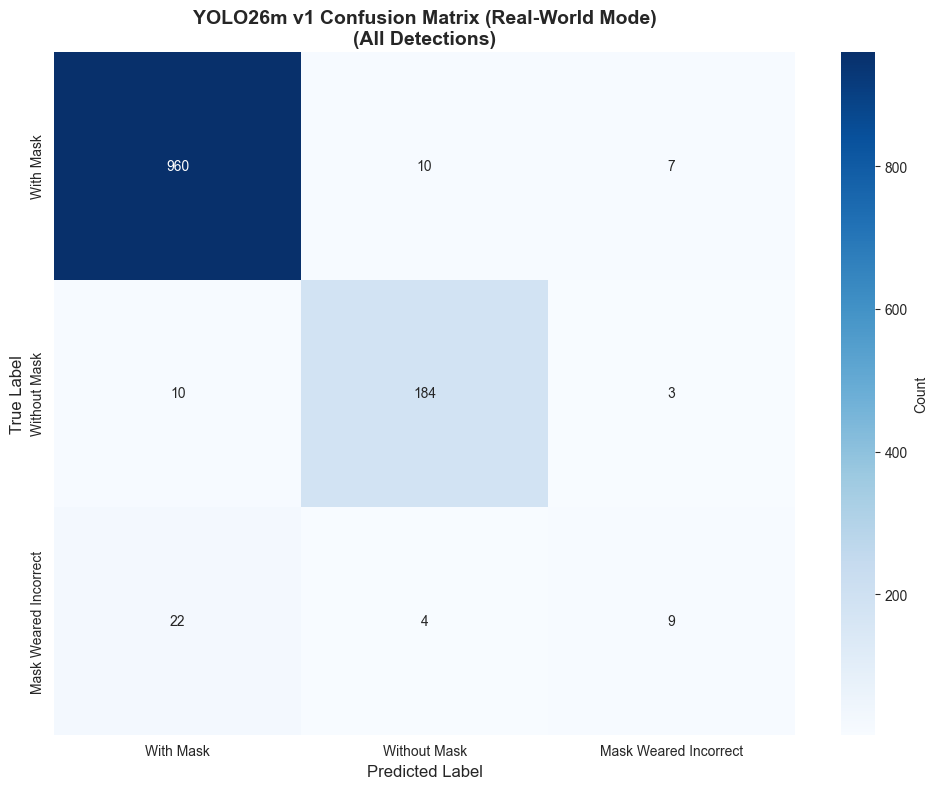

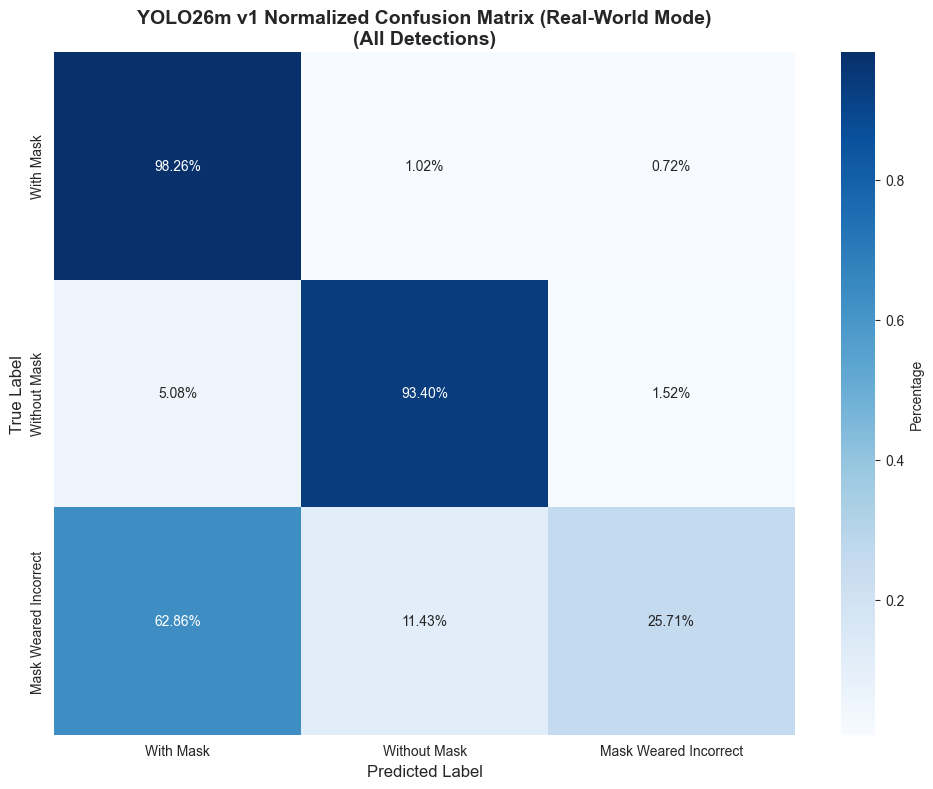

In [ ]:
# Confusion Matrix
if len(y_true) > 0:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={'label': 'Count'})
    plt.title('YOLO26m v1 Confusion Matrix\n(Matched Detections Only)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={'label': 'Percentage'})
    plt.title('YOLO26m v1 Normalized Confusion Matrix\n(Matched Detections Only)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

## Detailed Classification Report

In [ ]:
# Classification Report
if len(y_true) > 0:
    print("=" * 80)
    print("DETAILED CLASSIFICATION REPORT")
    print("=" * 80)
    print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))
    print("=" * 80)

DETAILED CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.97      0.98      0.98       977
         Without Mask       0.93      0.93      0.93       197
Mask Weared Incorrect       0.47      0.26      0.33        35

             accuracy                           0.95      1209
            macro avg       0.79      0.72      0.75      1209
         weighted avg       0.95      0.95      0.95      1209



## Visualize Sample Predictions

Show sample images with ground truth (green) and predictions (colored by class).

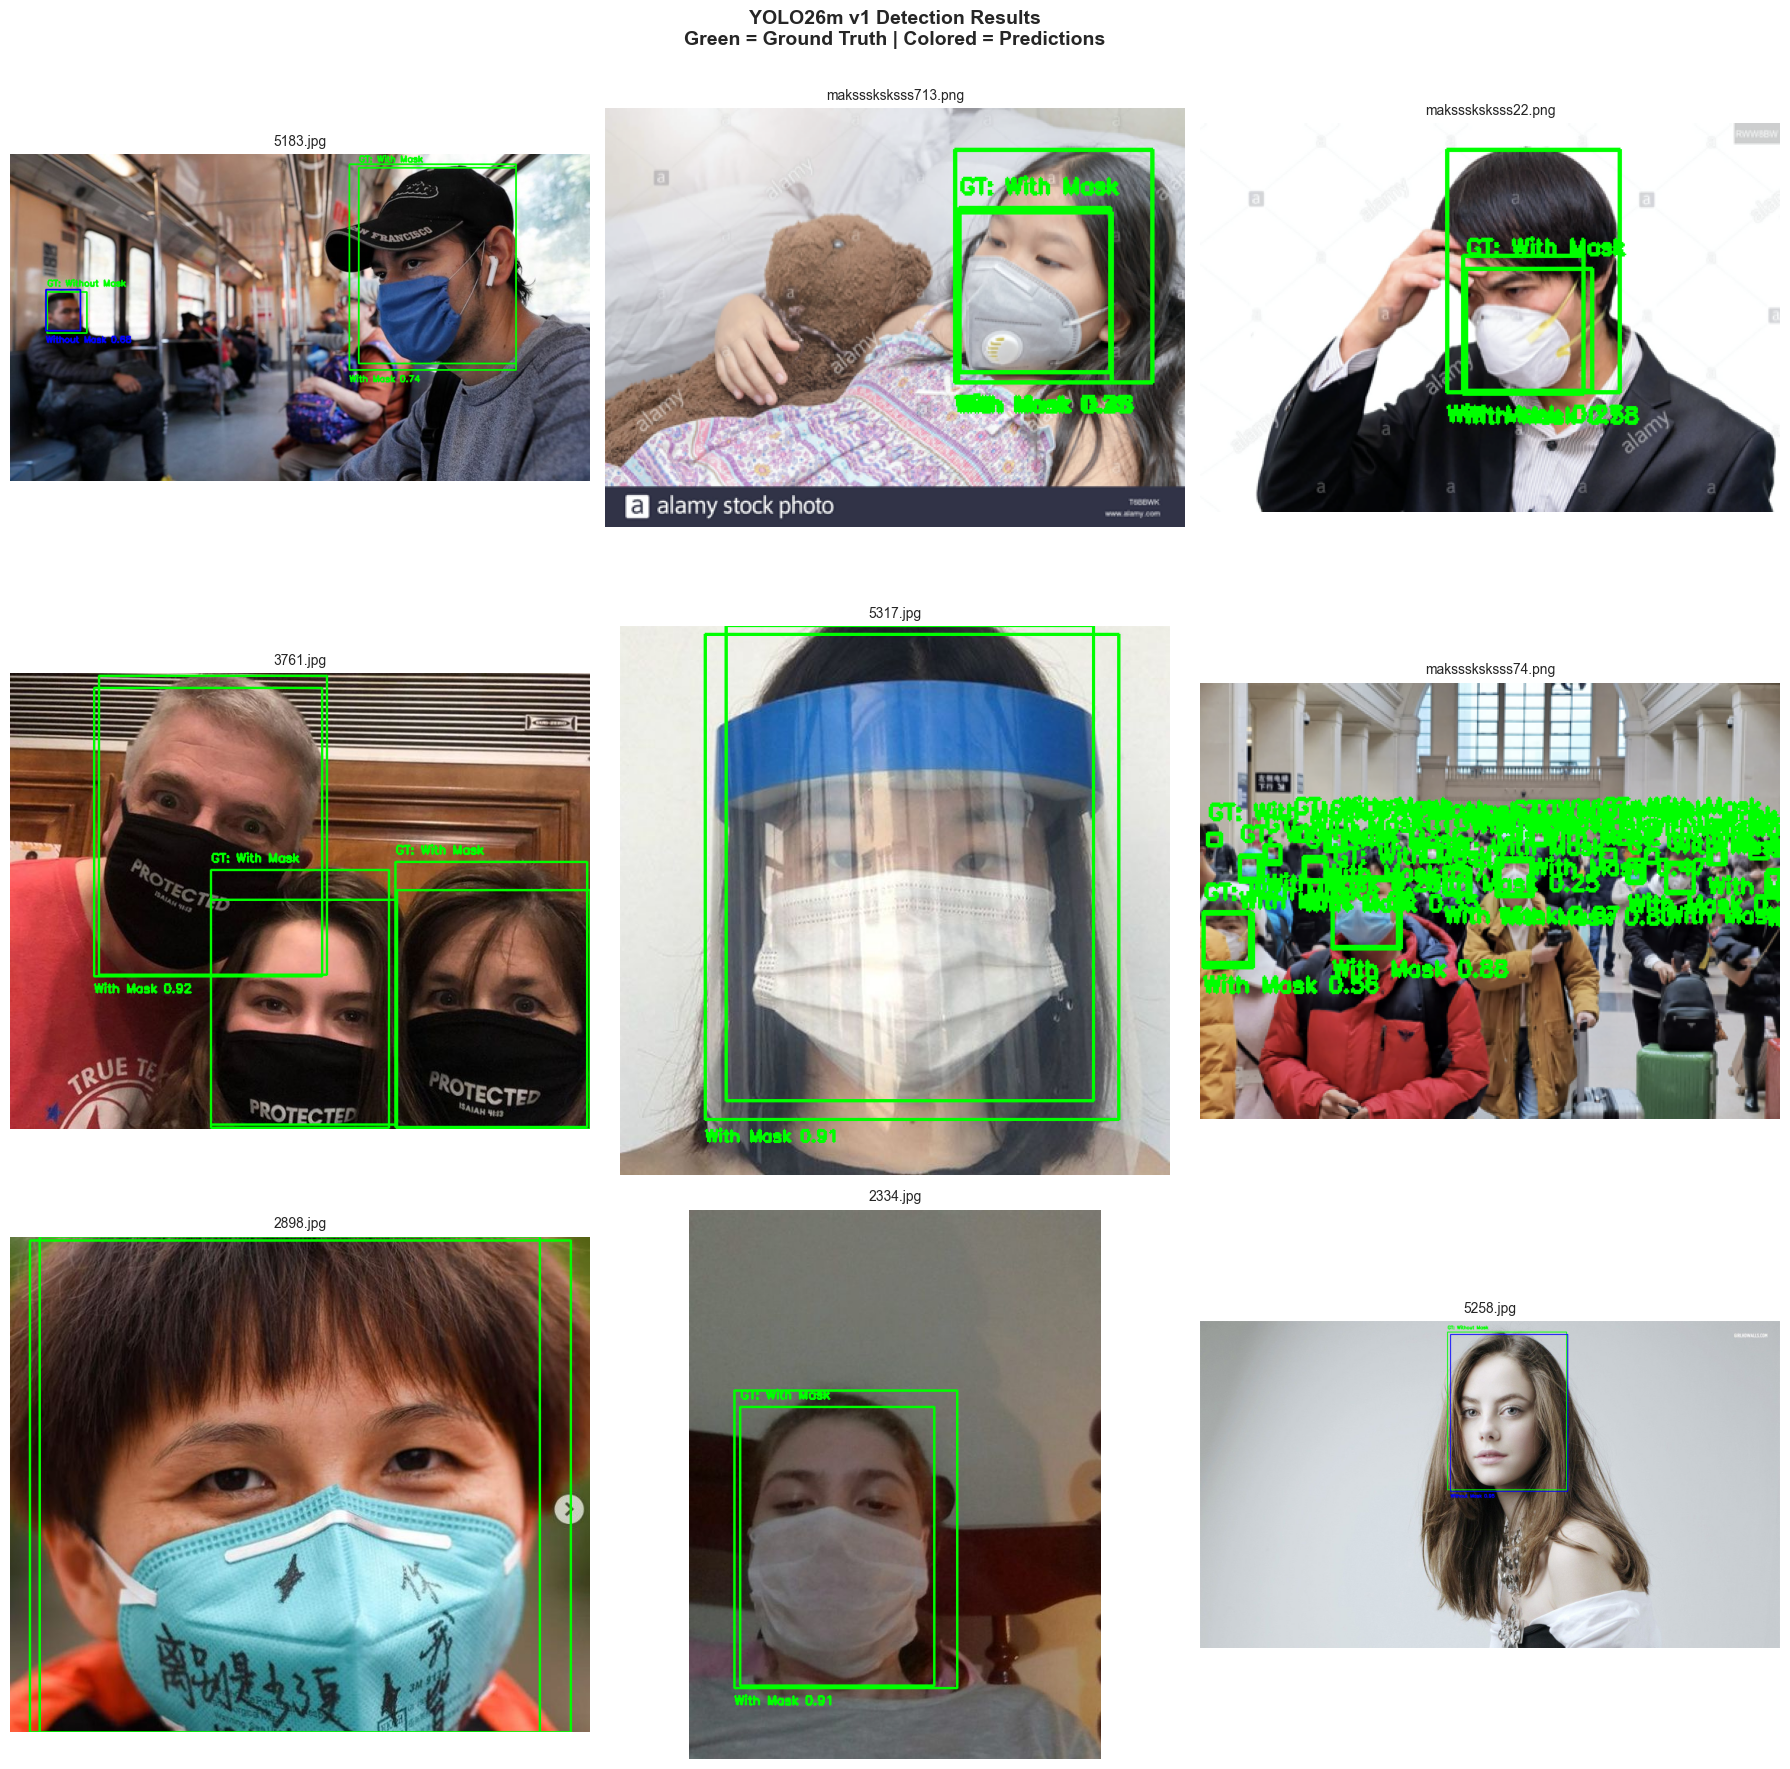

In [29]:
# Visualize sample predictions
num_samples = 9
sample_indices = np.random.choice(len(test_images), min(num_samples, len(test_images)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

for idx, img_idx in enumerate(sample_indices):
    img_path = test_images[img_idx]
    
    # Read image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Draw ground truth boxes in green
    for gt_class, center_x, center_y, bbox_w, bbox_h in gt_labels:
        gt_x1, gt_y1, gt_x2, gt_y2 = convert_yolo_to_pixel_coords(
            (center_x, center_y, bbox_w, bbox_h), img_w, img_h
        )
        cv2.rectangle(img_rgb, (gt_x1, gt_y1), (gt_x2, gt_y2), (0, 255, 0), 2)
        cv2.putText(img_rgb, f'GT: {CLASS_NAMES[gt_class]}', 
                   (gt_x1, gt_y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                   0.5, (0, 255, 0), 2)
    
    # Run prediction
    results = yolo_model(str(img_path), verbose=False)
    
    # Draw predictions
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, xyxy)
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                
                # Color by class
                color = CLASS_COLORS[pred_class]
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_rgb, f'{CLASS_NAMES[pred_class]} {confidence:.2f}', 
                           (x1, y2 + 20), cv2.FONT_HERSHEY_SIMPLEX, 
                           0.5, color, 2)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f'{img_path.name}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('YOLO26m v1 Detection Results\nGreen = Ground Truth | Colored = Predictions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## IoU Distribution Analysis

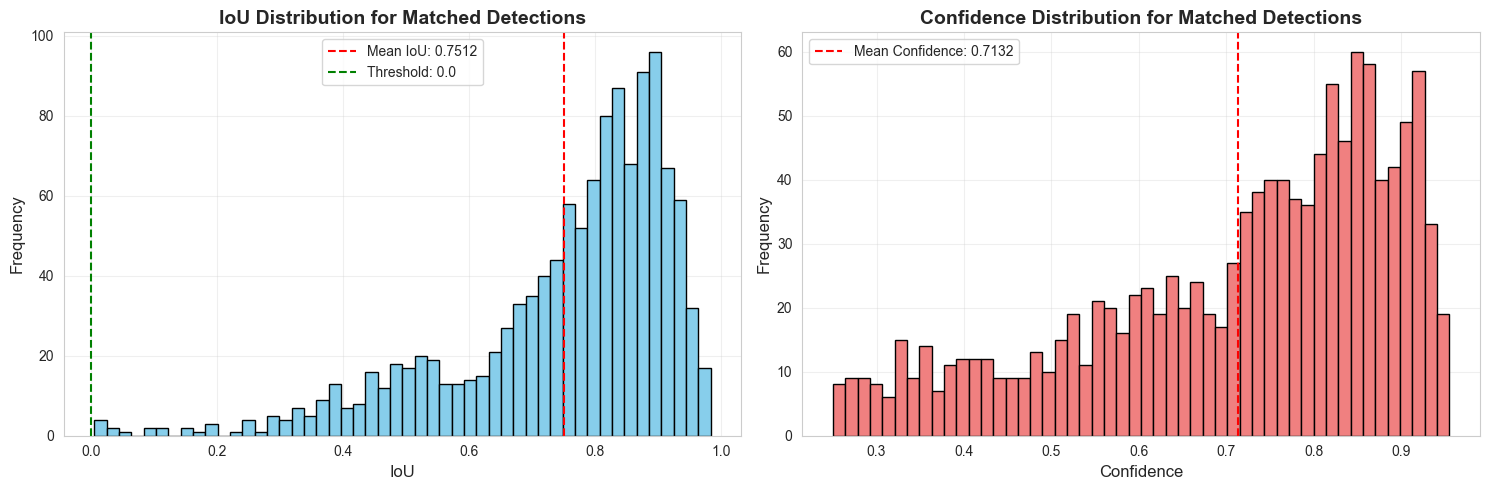


IoU Statistics:
  Mean:   0.7512
  Median: 0.8059
  Std:    0.1763
  Min:    0.0053
  Max:    0.9834

Confidence Statistics:
  Mean:   0.7132
  Median: 0.7603
  Std:    0.1789
  Min:    0.2502
  Max:    0.9546


In [30]:
# IoU distribution
if len(ious) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # IoU histogram
    axes[0].hist(ious, bins=50, color='skyblue', edgecolor='black')
    axes[0].axvline(np.mean(ious), color='red', linestyle='--', 
                    label=f'Mean IoU: {np.mean(ious):.4f}')
    axes[0].axvline(iou_threshold, color='green', linestyle='--', 
                    label=f'Threshold: {iou_threshold}')
    axes[0].set_xlabel('IoU', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('IoU Distribution for Matched Detections', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Confidence histogram
    axes[1].hist(confidences, bins=50, color='lightcoral', edgecolor='black')
    axes[1].axvline(np.mean(confidences), color='red', linestyle='--', 
                    label=f'Mean Confidence: {np.mean(confidences):.4f}')
    axes[1].set_xlabel('Confidence', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Confidence Distribution for Matched Detections', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\nIoU Statistics:")
    print(f"  Mean:   {np.mean(ious):.4f}")
    print(f"  Median: {np.median(ious):.4f}")
    print(f"  Std:    {np.std(ious):.4f}")
    print(f"  Min:    {np.min(ious):.4f}")
    print(f"  Max:    {np.max(ious):.4f}")
    
    print("\nConfidence Statistics:")
    print(f"  Mean:   {np.mean(confidences):.4f}")
    print(f"  Median: {np.median(confidences):.4f}")
    print(f"  Std:    {np.std(confidences):.4f}")
    print(f"  Min:    {np.min(confidences):.4f}")
    print(f"  Max:    {np.max(confidences):.4f}")

## Summary

**Model:** YOLO26m v1 (face_mask_detection_yolo26m_v1_best.pt)

**Evaluation Mode:** Matched detections with IoU matching
- Classification metrics computed on matched detections only (IoU > 0 with ground truth)
- Detection statistics (false positives, missed faces) reported separately
- Confusion matrix and classification report reflect classification accuracy on valid detections

**Key Metrics:**
- Detection Rate: % of ground truth faces successfully detected
- Classification Accuracy: % of matched detections classified correctly
- IoU Distribution: Quality of bounding box localization
- Confusion Matrix: Class-wise classification performance on matched detections